# CorroborIA : corroboration intelligente RH (système A) vers Temps (système B)

**Défi Loto-Québec n°14.** Comparer, champ par champ, l'extraction du système A (RH, source de vérité) et celle du
système B (Temps, cible) selon `Mapping.xlsx`, puis classer chaque contrôle et **expliquer** chaque verdict.

| Verdict | Sens | Qui décide |
|---|---|---|
| Conforme (`OK`) | la valeur de B est celle attendue d'après A | règle du mapping |
| Écart justifié (`ECART_JUSTIFIE`) | valeurs différentes mais expliquées (encodage, anonymisation, norme du poste) | règle ou modèle IA |
| Vraie anomalie (`ERREUR`) | écart non expliqué, à investiguer | règle du mapping (ou expert) |
| À relire (`A_REVUE_HUMAINE`) | confiance sous le seuil : un humain tranche | seuil réglable |

Origine d'un verdict : **règle** du mapping, **IA** locale, **expert** (correction manuelle) ou **règle apprise** (proposée à partir des corrections d'experts, puis validée par un expert).

**Approche hybride en trois niveaux** : règles déterministes, modèle scikit-learn local pour les cas ambigus,
LLM local (Ollama) pour rédiger les explications. Aucune donnée ne quitte la machine ; les fichiers sources sont en lecture seule.

## 1. Préparation

In [1]:
import sys, os, json, subprocess
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "source" / "corroboria.py").exists():      # notebook lancé depuis un sous-dossier
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "source"))

import pandas as pd
import matplotlib.pyplot as plt
import corroboria, ia, llm

pd.set_option("display.max_colwidth", 70, "display.width", 200)
LABEL = {"OK": "Conforme", "ECART_JUSTIFIE": "Écart justifié", "ERREUR": "Vraie anomalie", "A_REVUE_HUMAINE": "À relire"}
COULEUR = {"OK": "#2e9e5b", "ECART_JUSTIFIE": "#e0b020", "ERREUR": "#d64545", "A_REVUE_HUMAINE": "#e8892b"}
print("Projet :", ROOT)

Projet : C:\Users\nicol\OneDrive\Documents\Hackathlon


## 2. Les données
Quatre fichiers (dans `data/`) : extraction **A** (RH), extraction **B** (Temps), la table des motifs de situation d'emploi et le
détail du poste. Le fichier `Mapping.xlsx` définit les champs à corroborer ; tout champ non mappé est ignoré, comme l'énoncé l'exige.

In [2]:
for f in sorted((ROOT / "data").glob("*.xlsx")):
    xl = pd.ExcelFile(f)
    for feuille in xl.sheet_names:
        d = xl.parse(feuille)
        print(f"{f.name:45s} [{feuille}] {d.shape[0]:>4} lignes x {d.shape[1]:>3} colonnes")

détail_du_poste.xlsx                          [Feuil1]  114 lignes x   1 colonnes
Employe_Destination_Anonymise_VF.xlsx         [Employe_Destination]   22 lignes x  79 colonnes
Employe_Source_Anonymise_VF.xlsx              [Employe_Source]   23 lignes x  33 colonnes
Mapping.xlsx                                  [Mapping]   57 lignes x   4 colonnes
Mapping.xlsx                                  [Règles situation d'emploi]    2 lignes x   4 colonnes
Mapping.xlsx                                  [Jointure - Détail du poste]    8 lignes x   2 colonnes
Mapping.xlsx                                  [Jointure - Motif des situations]    5 lignes x   2 colonnes
Motif de la situation d'emploi.xlsx           [Sheet1]   92 lignes x   3 colonnes


In [3]:
corroboria.glossary_fields().head(12)   # champs à corroborer, lus dans Mapping.xlsx

,Description,Champ système A,Champ système B,Règle
0,Prénom de l’employé,PrénomUsuel,givenName,Copie directe
1,Nom de l’employé,NomFamille,surname,Copie directe
2,Email de l’employé,Adresse courriel travail,contactEmail,Mettre la valeur suivante : Première lettre du prénom + nom + 3 de...
3,Date d’embauche,DateEmbaucheRécente,onboardDate,Copie directe
4,Code de l’employé,Matricule,personId,Copie directe
5,Emplacement,LibelléSite,siteName,Copie directe
6,Code d’emplacement,CodeSite,siteCode,Copie directe
7,Département,CodeDirection,divisionId,Copie directe
8,NaN,LibelléDirection,divisionName,Concaténation de Unité adm. + “-“ +Unité adm. desc
9,Code de département,CodeImputation,divisionCode,Copie directe


## 3. Niveau 1 : le moteur de règles
`corroboria.run()` applique le mapping champ par champ : noms sans accents, courriel (initiale + nom + 3 derniers chiffres),
type de contrat selon le type d'employé, affectation principale / temporaire, situation d'emploi via la table des motifs,
heures (norme du poste), dates. Chaque ligne porte la **règle appliquée** et une **explication**.

In [4]:
brut = corroboria.run()
print(f"{len(brut)} contrôles pour {brut.Matricule.nunique()} employés")
brut.groupby(["Nature", "Statut"]).size().rename("lignes").to_frame()

575 contrôles pour 20 employés


lignes
Nature      Statut                
heuristique ECART_JUSTIFIE      46
règle       ECART_JUSTIFIE       8
            ERREUR              13
            OK                 508

## 4. Niveau 2 : le modèle IA local (scikit-learn)
Les écarts que les règles ne peuvent pas trancher seules (courriel, libellé de poste, heures sans valeur source) sont confiés à un
RandomForest qui estime la probabilité d'erreur et retourne une **confiance**. Le modèle s'entraîne sur les verdicts sûrs des règles,
des cas synthétiques par perturbation et les corrections d'experts (`corrections.csv`). Il ne modifie jamais un verdict de règle.

In [5]:
df = ia.enrich(brut, exporter_modele=True)   # exporte aussi le modèle entraîné (modele/modele_corroboria.*)
df["Verdict"] = df.Statut.map(LABEL)
pd.crosstab(df.Verdict, df.Source_verdict, margins=True)

Source_verdict,IA,règle,All
Verdict,,,
Conforme,0,508,508
Vraie anomalie,0,13,13
Écart justifié,46,8,54
All,46,529,575


46 écarts tranchés par l'IA ; confiance moyenne 94.4% (min 88%, max 97%)


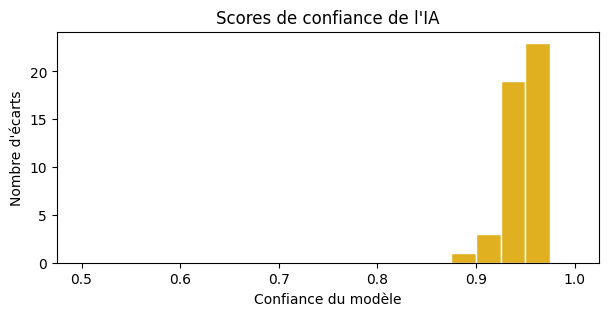

In [6]:
ia_rows = df[df.Source_verdict == "IA"]
print(f"{len(ia_rows)} écarts tranchés par l'IA ; confiance moyenne {ia_rows.Confiance.mean():.1%} "
      f"(min {ia_rows.Confiance.min():.0%}, max {ia_rows.Confiance.max():.0%})")
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ia_rows.Confiance, bins=[0.5 + 0.025 * i for i in range(21)], color=COULEUR["ECART_JUSTIFIE"], edgecolor="white")
ax.set(xlabel="Confiance du modèle", ylabel="Nombre d'écarts", title="Scores de confiance de l'IA")
plt.show()

**Modèle entraîné** : `RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=0)` sur 13 variables. Il est exporté
(`modele/modele_corroboria.joblib`) avec sa fiche (`modele/modele_corroboria.json`) et se **ré-entraîne à l'identique** avec `python source/corroboria.py` (graine fixe).

In [7]:
fiche = json.loads((ROOT / "modele" / "modele_corroboria.json").read_text(encoding="utf-8"))
print("Classes :", fiche["classes"], "| exemples d'entraînement :", fiche["exemples_entrainement"], "| corrections d'experts :", fiche["corrections_experts_utilisees"])
pd.Series(fiche["importance_des_variables"], name="importance").head(8).to_frame()

Classes : ['ECART_JUSTIFIE', 'ERREUR'] | exemples d'entraînement : 421 | corrections d'experts : 0


,importance
same_rep,0.253
sim,0.223
ref_match,0.208
contains,0.074
sev,0.061
len_ratio,0.060
day_diff,0.039
is_num,0.023


## 5. Résultat global

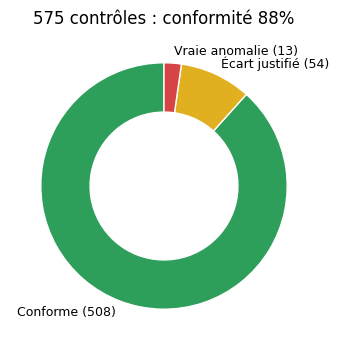

In [8]:
ordre = ["OK", "ECART_JUSTIFIE", "ERREUR", "A_REVUE_HUMAINE"]
n = df.Statut.value_counts().reindex(ordre, fill_value=0)
fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(n[n > 0], labels=[f"{LABEL[s]} ({n[s]})" for s in n[n > 0].index], colors=[COULEUR[s] for s in n[n > 0].index],
       wedgeprops=dict(width=0.4, edgecolor="white"), startangle=90, textprops={"fontsize": 9})
ax.set_title(f"{len(df)} contrôles : conformité {n['OK'] / len(df):.0%}")
plt.show()

## 6. Les vraies anomalies, classées par priorité
Chaque anomalie vient d'une **règle du mapping** (colonne `Règle`) ; le score 0-100 combine la gravité du champ (60 %),
la confiance (25 %) et la récurrence du champ (15 %). `Cause_probable` regroupe les écarts qui partagent la même origine.

In [9]:
anom = df[df.Statut == "ERREUR"].sort_values("Priorité", ascending=False)
anom[["Priorité", "Matricule", "Champ", "ValeurSourceA", "ValeurDestB", "Règle", "Cause_probable"]].reset_index(drop=True)

,Priorité,Matricule,Champ,ValeurSourceA,ValeurDestB,Règle,Cause_probable
0,94,2762457,contractTypeCode,JWN,WHX,Règle type d'employé (PERM/FT/EMPTP),4 écarts distincts sur contractTypeCode : propagation incomplète p...
1,94,4625374,contractTypeCode,WHX,JWN,Règle type d'employé (PERM/FT/EMPTP),4 écarts distincts sur contractTypeCode : propagation incomplète p...
2,94,7254364,contractTypeCode,XFLR,JWN,Règle type d'employé (PERM/FT/EMPTP),4 écarts distincts sur contractTypeCode : propagation incomplète p...
3,94,3712987,contractTypeCode,JWN,XFLR,Règle type d'employé (PERM/FT/EMPTP),4 écarts distincts sur contractTypeCode : propagation incomplète p...
4,91,2911996,weeklyHoursOverride,35.0,40,Heures norme poste,B contient toujours « 40 » (3 lignes) : valeur par défaut probable
5,91,4402456,dailyHoursOverride,7.2,8,Heures norme poste,B contient toujours « 8 » (3 lignes) : valeur par défaut probable
6,91,4402456,weeklyHoursOverride,36.0,40,Heures norme poste,B contient toujours « 40 » (3 lignes) : valeur par défaut probable
7,91,7683990,weeklyHoursOverride,36.0,40,Heures norme poste,B contient toujours « 40 » (3 lignes) : valeur par défaut probable
8,91,2911996,dailyHoursOverride,7.0,8,Heures norme poste,B contient toujours « 8 » (3 lignes) : valeur par défaut probable
9,91,7683990,dailyHoursOverride,7.2,8,Heures norme poste,B contient toujours « 8 » (3 lignes) : valeur par défaut probable


In [10]:
print(f"{anom.Matricule.nunique()} employés concernés sur {df.Matricule.nunique()}")
anom.groupby("Règle").size().sort_values(ascending=False).rename("anomalies").to_frame().head(10)

10 employés concernés sur 20


,anomalies
Règle,
Heures norme poste,6
Règle type d'employé (PERM/FT/EMPTP),4
LibelléSite,2
Complétude,1


## 7. Les écarts justifiés (extrait)
Écarts attendus d'après le contexte (préfixe `dev-` des courriels, nom de poste concaténé, encodage) : ils ne remontent pas.

In [11]:
just = df[df.Statut == "ECART_JUSTIFIE"]
just.groupby(["Source_verdict", "Règle"]).size().rename("lignes").to_frame()

lignes
Source_verdict Règle                                                                         
IA             Concaténation emploi + '-' + description                                    22
               Gabarit courriel                                                            22
               Heures norme poste                                                           2
règle          Date d'effet du détail du poste : source = date d'effet du poste (D...       3
               Date de début d'affectation : source = date d'effet du poste (DateE...       3
               Encodage                                                                     2

In [12]:
just[["Matricule", "Champ", "ValeurSourceA", "ValeurDestB", "Source_verdict", "Confiance"]].head(6)

,Matricule,Champ,ValeurSourceA,ValeurDestB,Source_verdict,Confiance
3,1545850,contactEmail,PNom1545850850@loto-quebec.com,dev-08-v2_PNom10370370@loto-quebec.com,IA,0.93
13,1545850,positionName,6585-Empl6585,3649-Empl3649,IA,0.97
30,9989151,contactEmail,PNom9989151151@loto-quebec.com,dev-08-v2_PNom10372372@loto-quebec.com,IA,0.93
40,9989151,positionName,6203-Empl6203,4367-Empl4367,IA,0.96
44,9989151,assignmentStartDate,2009-03-30,2021-03-30,règle,1.00
45,9989151,termStartDate,2009-03-30,2021-03-30,règle,1.00


## 8. Le seuil de confiance : « À relire »
Tout écart non conforme dont la confiance est **sous le seuil** passe en « À relire » (validation humaine). Les anomalies décidées par
une règle ont 100 % de confiance : elles ne passent jamais en « À relire ». Dans l'application, le seuil est un curseur et
l'anneau du tableau de bord se met à jour.

In [13]:
lignes = []
for seuil in (0.50, 0.80, 0.90, 0.95, 1.00):
    s = df.Statut.where(~((df.Statut != "OK") & (df.Confiance < seuil)), "A_REVUE_HUMAINE").value_counts()
    lignes.append({"Seuil": f"{seuil:.0%}", **{LABEL[k]: int(s.get(k, 0)) for k in ordre}})
pd.DataFrame(lignes).set_index("Seuil")

,Conforme,Écart justifié,Vraie anomalie,À relire
Seuil,,,,
50%,508,54,13,0
80%,508,54,13,0
90%,508,53,13,1
95%,508,31,13,23
100%,508,8,13,46


## 9. Le score de priorité est paramétrable
Les poids (`ia.WEIGHTS`) et la gravité par champ (`ia.SEVERITY`) sont modifiables dans l'onglet *Paramètres* de l'application.
Exemple : donner tout le poids à la récurrence change le classement.

In [14]:
print("Poids par défaut :", ia.WEIGHTS)
d2 = df.assign(Priorité=ia.priorite(df, {"gravite": 0.1, "confiance": 0.1, "recurrence": 0.8}))
comp = pd.DataFrame({"par défaut": df.Priorité, "récurrence 80 %": d2.Priorité, "Champ": df.Champ, "Matricule": df.Matricule})
comp[df.Statut == "ERREUR"].sort_values("par défaut", ascending=False).head(8).reset_index(drop=True)

Poids par défaut : {'gravite': 0.6, 'confiance': 0.25, 'recurrence': 0.15}


,par défaut,récurrence 80 %,Champ,Matricule
0,94,99,contractTypeCode,2762457
1,94,99,contractTypeCode,4625374
2,94,99,contractTypeCode,7254364
3,94,99,contractTypeCode,3712987
4,91,99,weeklyHoursOverride,2911996
5,91,99,dailyHoursOverride,4402456
6,91,99,weeklyHoursOverride,4402456
7,91,99,weeklyHoursOverride,7683990


## 10. Niveau 3 : explication par LLM local (à la demande)
Le LLM (Ollama, `qwen2.5:3b` par défaut, 1.5b « rapide » ou 7b « précis ») **ne change jamais un verdict**. Pour que ses conseils soient
compréhensibles, le code lui donne, pour la ligne choisie : la **fiche du champ** retrouvée dans le glossaire de `Mapping.xlsx` (description,
colonne du système A, règle) et dans `glossaire_ia.json` (explication en langage courant, modifiable), les **codes** de la ligne traduits
(JWN = permanent temps plein) et les **valeurs décodées** (« 6900-Empl6900 » = emploi 6900, description Empl6900). Il répond en 3 phrases :
ce que c'est, ce qu'on voit, à vérifier. Il n'est appelé que sur demande ; les réponses sont mises en cache. Si Ollama est absent,
on garde l'explication par gabarit. Sur un poste équipé d'un GPU NVIDIA, Ollama l'utilise automatiquement.

In [15]:
print("GPU NVIDIA détecté :", llm.gpu_info() or "aucun (calcul sur CPU)")
top = anom.iloc[0]
print("\nLigne :", top.Matricule, top.Champ, "| A =", top.ValeurSourceA, "| B =", top.ValeurDestB)
print("\n----- Ce que le LLM reçoit (extrait) -----")
print(llm._prompt(top)[:1400])

GPU NVIDIA détecté : aucun (calcul sur CPU)

Ligne : 2762457 contractTypeCode | A = JWN | B = WHX

----- Ce que le LLM reçoit (extrait) -----
FICHE DU CHAMP
- Champ contractTypeCode = « Type d’employé » (colonne « CatégorieEmploi » du système A). Règle du mapping : SI PERM_IND=1 et FT_IND=1 et EMPTP_CD="V" --> Mettre "JWN"  SI PERM_IND=1 et FT_IND=0 et EMPTP_CD="V" --> Mettre "XFLR"  SI EMPTP_CD="T" (Surnuméraire avec vacances) --> Mettre "KELH"  SI EMPTP_CD="O" (Occasionnel - Surnuméraire) --> Mettre "WHX"  SI EMPTP_CD="M" (Occasionnel avec avantages) --> […]
- Pour comprendre : Type d'employé (permanent temps plein, permanent temps partiel, occasionnel, surnuméraire, saisonnier, stagiaire…), déduit de la catégorie d'emploi du système RH. Chaque code a une signification (voir les codes de la ligne).
Codes de la ligne : JWN = Permanent temps plein (PERM_IND=1, FT_IND=1, EMPTP_CD=V); WHX = Occasionnel – surnuméraire (O)

LECTURE DES VALEURS
- Système A : JWN = Permanent temps plein (PER

In [16]:
if llm.available():
    texte = llm.cached(top) or llm.explain_row(top)
    print("Explication du LLM local :\n", texte)
else:
    print("Ollama / modèle non disponible sur cette machine : explication par gabarit conservée.")

Explication du LLM local :
 Ce que c'est : le type d’emploi, déterminant par les catégories dans le système RH. Ce qu'on voit : le système A indique "JWN" pour un emploi permanent temps plein et le système B indique "WHX" pour une situation occasionnelle surnuméraire.
À vérifier : la catégorie d'emploi de cet employé, car cela permettra de déterminer si c'est bien l'un ou l'autre qui a raison. Pourquoi ce verdict : à relire (écart justifié), car le modèle penchait pour un écart acceptable avec 100% de confiance.


## 11. Retours d'experts et règles apprises
Un expert fonctionnel peut corriger un verdict dans l'application (liste déroulante du statut, **confirmation**, motif, commentaire, auteur).
La correction est gardée dans un **journal** (`corrections.csv`, historique conservé, annulable) et sert de trois façons :
1. elle **remplace** le verdict de la ligne (origine « expert ») ;
2. elle **enrichit l'entraînement** du modèle local (poids élevé) ;
3. quand **3 corrections concordantes** existent (même champ, même « forme » des valeurs A et B, même verdict, aucun contre-exemple), une
   **règle est proposée** à l'expert, qui la valide ou la rejette. Une règle validée (`regles_apprises.json`) est appliquée par le moteur,
   distincte des règles du mapping. Rien n'est appliqué automatiquement sans validation.

La simulation ci-dessous utilise des fichiers temporaires : les vrais journaux ne sont pas modifiés.

In [17]:
import tempfile
from IPython.display import display
import retours

vrais = (retours.JOURNAL, retours.REGLES)
tmp = Path(tempfile.mkdtemp())
retours.JOURNAL, retours.REGLES = tmp / "corrections.csv", tmp / "regles_apprises.json"   # simulation uniquement

cibles = df[(df.Champ == "positionName") & (df.Statut != "OK")].head(3)    # 3 libellés que l'expert juge erronés
for r in cibles.itertuples():
    retours.ajouter(r.Matricule, r.Champ, "ERREUR", motif="erreur_confirmee", commentaire="numéro d'emploi différent",
                    auteur="expert1", valeur_a=r.ValeurSourceA, valeur_b=r.ValeurDestB, regle=r.Règle, ancien=r.Statut)
print(f"Seuil de proposition : {retours.SEUIL_REGLE} corrections concordantes")
retours.lire_journal()[["Matricule", "Champ", "Verdict", "Motif", "Auteur", "Date", "ValeurA", "ValeurB"]]

Seuil de proposition : 3 corrections concordantes


,Matricule,Champ,Verdict,Motif,Auteur,Date,ValeurA,ValeurB
0,1545850,positionName,ERREUR,erreur_confirmee,expert1,2026-10-04 09:23,6585-Empl6585,3649-Empl3649
1,9989151,positionName,ERREUR,erreur_confirmee,expert1,2026-10-04 09:23,6203-Empl6203,4367-Empl4367
2,8142123,positionName,ERREUR,erreur_confirmee,expert1,2026-10-04 09:23,6203-Empl6203,4367-Empl4367


In [18]:
prop = retours.propositions()
for p in prop:
    print(f"Règle proposée : champ {p['champ']} ; valeur A de forme « {p['forme_a']} » et valeur B de forme « {p['forme_b']} » "
          f"=> {p['verdict']} ({p['n']} corrections, ex. {', '.join(p['exemples'])})")

Règle proposée : champ positionName ; valeur A de forme « #-Empl# » et valeur B de forme « #-Empl# » => ERREUR (3 corrections, ex. 1545850, 9989151, 8142123)


In [19]:
avant = df[df.Champ == "positionName"].Statut.value_counts()
retours.valider(prop[0], "expert1")                      # l'expert valide la règle
apres = ia.enrich(brut)
pos = apres[(apres.Champ == "positionName") & (apres.Statut != "OK")]
print("Libellés de poste en écart, avant :", {k: int(v) for k, v in avant.items()}, "\naprès la règle validée :")
display(pos.groupby(["Statut", "Source_verdict"]).size().rename("lignes").to_frame())
print("Effet des retours sur l'ensemble des verdicts :", ia.effet_retours(brut))
retours.JOURNAL, retours.REGLES = vrais                  # on remet les vrais fichiers

Libellés de poste en écart, avant : {'ECART_JUSTIFIE': 22} 
après la règle validée :


lignes
Statut Source_verdict        
ERREUR expert               3
       règle apprise       19

Effet des retours sur l'ensemble des verdicts : {'corriges_par_expert': 3, 'changes_par_regles_apprises': 19, 'changes_par_le_modele': 0, 'total_changes': 22}


## 12. L'assistant (chatbot) : questions courantes et pilotage de l'écran
Dans l'application, une bulle en bas à droite ouvre un assistant. Il répond aux **questions courantes** (comptages, employé ou champ le plus touché,
définitions du glossaire, avancement) et **pilote l'écran** (« montre-moi les anomalies de l'employé X » règle les filtres du tableau,
« mets le seuil à 95 », « explique cette ligne » ouvre le bandeau IA). Le code comprend la question et **calcule sur les données** : les chiffres ne
viennent jamais d'un modèle ; le LLM local n'intervient que pour expliquer une ligne. L'assistant est en **lecture seule**.

In [20]:
import assistant
ctx = {"restant": int((df.Statut == "A_REVUE_HUMAINE").sum()), "total": int((df.Statut == "A_REVUE_HUMAINE").sum())}
for q in ["Combien de vraies anomalies ?", "Quel employé a le plus d'anomalies ?", "C'est quoi positionName ?",
          "Montre-moi les anomalies de l'employé 3712987", "Mets le seuil à 95", "Quelle est la capitale de la France ?"]:
    r = assistant.repondre(q, df, "fr", ctx)
    print("Q :", q, "\nR :", r["texte"].replace("\n", " | ")[:260], "\nActions :", r["actions"], "\n")

Q : Combien de vraies anomalies ? 
R : Il y a **13** ligne(s) (vraie anomalie). Répartition par champ : contractTypeCode (4), dailyHoursOverride (3), weeklyHoursOverride (3). Dis « montre-moi » pour les afficher dans le tableau. 
Actions : {} 

Q : Quel employé a le plus d'anomalies ? 
R : Employés avec le plus de lignes « vraie anomalie » : 4402456 (2), 2911996 (2), 7683990 (2). 
Actions : {} 

Q : C'est quoi positionName ? 
R : **positionName** | - Champ positionName = « Nom du rôle » (colonne « IntituléEmploi » du système A). Règle du mapping : Concaténation de Emploi + “-“ + Emploi desc | - Pour comprendre : Nom du rôle au format <numéro d'emploi>-<description de l'emploi>, par exe 
Actions : {} 

Q : Montre-moi les anomalies de l'employé 3712987 
R : J'ai filtré le tableau : **1** ligne(s) (vraie anomalie) pour l'employé 3712987. Descends à « Données sélectionnées ». 
Actions : {'statuts': ['ERREUR'], 'champs': [], 'employe': '3712987'} 

Q : Mets le seuil à 95 
R : Seuil de confi

## 13. Exports
Rapport Excel (onglets : vraies anomalies, à relire, écarts justifiés, résumé par champ, détail) et CSV (séparateur `;`, UTF-8 avec BOM).

In [21]:
corroboria.report(df)
for f in sorted((ROOT / "outputs").glob("rapport_corroboration*.xlsx")):
    print(f.name, f"{f.stat().st_size / 1024:.0f} Ko")
dernier = max((ROOT / "outputs").glob("rapport_corroboration*.xlsx"), key=lambda f: f.stat().st_mtime)   # le plus récent (si le rapport habituel est ouvert dans Excel)
print("Feuilles :", pd.ExcelFile(dernier).sheet_names)

(rapport habituel verrouillé, écriture dans rapport_corroboration_092357.xlsx)


575 contrôles : 508 OK, 54 écarts justifiés, 13 erreurs à investiguer, 0 à relire
 Priorité  Matricule               Champ ValeurSourceA   ValeurDestB Source_verdict                                                            Cause_probable
       94    2762457    contractTypeCode           JWN           WHX          règle 4 écarts distincts sur contractTypeCode : propagation incomplète probable
       94    4625374    contractTypeCode           WHX           JWN          règle 4 écarts distincts sur contractTypeCode : propagation incomplète probable
       94    7254364    contractTypeCode          XFLR           JWN          règle 4 écarts distincts sur contractTypeCode : propagation incomplète probable
       94    3712987    contractTypeCode           JWN          XFLR          règle 4 écarts distincts sur contractTypeCode : propagation incomplète probable
       91    2911996 weeklyHoursOverride          35.0            40          règle        B contient toujours « 40 » (3 lignes)

## 14. Tests automatiques
Les tests `pytest` servent aussi de démonstration : un cas conforme, un écart justifié, une vraie anomalie, plus les règles métier,
l'export, le glossaire, la non-modification des sources, le mode GPU/CPU du LLM, la fiche du glossaire donnée au LLM, l'assistant (chatbot) et les retours d'experts (journal, annulation, règle proposée à partir de 3 corrections, validation, priorité de l'expert).

In [22]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--no-header", "--color=no"], capture_output=True, text=True, cwd=ROOT)
print(r.stdout[-600:])

........................................................................ [ 98%]
.                                                                        [100%]
73 passed in 19.79s



## 15. Hypothèses et limites
- **Dates de début** (`assignmentStartDate`, `termStartDate`) : la source (`DateEntréePoste`) est la date d'effet du poste seulement ; B inclut la
  règle transformée. Les données montrent « la plus récente entre `DateEntréePoste` et la date d'effet du dernier détail du poste » (le mapping
  parle de « la plus ancienne ») ; hypothèse à confirmer avec les organisateurs.
- **Pas de vérité terrain** : le modèle s'entraîne sur les règles sûres, des cas synthétiques et les corrections d'experts (journal `corrections.csv`) ; les règles apprises ne sont proposées qu'à partir de 3 corrections concordantes et appliquées après validation. Sur 22 lignes sources,
  ses scores sont indicatifs. Sur cet échantillon, il tranche 46 écarts, tous justifiés ; il est cohérent avec les règles mais n'a pas prouvé
  qu'il détecte des anomalies qu'elles auraient manquées.
- **Artefacts d'anonymisation** : préfixe `dev-` du courriel et nom de poste réécrit sont traités comme justifiés ; à revoir sur des données réelles.
- **Confidentialité** : tout est local (pandas, scikit-learn, Ollama sur localhost). Aucun appel réseau.

## 16. Lancer l'application
```
pip install -r requirements.txt
python -m streamlit run app.py
```
Tableau de bord interactif, curseur de seuil, section « À faire » avec suivi de progression, vérification ligne par ligne,
paramètres du score de priorité, bascule français / anglais.